In [17]:
from sklearn.ensemble import IsolationForest
import joblib
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

import pickle

import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


In [4]:
# Load 
df_features = pd.read_parquet("lfbo/processed/features.parquet")
meta_cols = ["icao24", "callsign", "source_date", "cluster_id", "is_noise", "is_arriving", "is_departing", "is_transiting"]
feature_cols = [c for c in df_features.columns if c not in meta_cols]
imputer       = joblib.load("lfbo/processed/imputer.pkl")
robust_scaler = joblib.load("lfbo/processed/robust_scaler.pkl")

X_imputed = imputer.transform(df_features[feature_cols])
X_final   = robust_scaler.transform(X_imputed)

df_final = pd.DataFrame(X_final, columns=feature_cols)

X_final = df_final.values
meta    = df_features[meta_cols].copy()

# Isolation Forest ────────────────────────────────────────
iso = IsolationForest(
    n_estimators=200,
    contamination=0.015,   # derived from real data
    random_state=42,
    n_jobs=-1
)
iso.fit(X_final)

meta["iforest_label"] = iso.predict(X_final)
meta["iforest_score"] = iso.decision_function(X_final)

print(f"Isolation Forest anomalies: "
      f"{(meta['iforest_label']==-1).sum()} "
      f"({(meta['iforest_label']==-1).mean()*100:.1f}%)")

# DBSCAN signal ───────────────────────────────────────────
meta["dbscan_noise"] = (meta["cluster_id"] == -1).astype(int)
print(f"DBSCAN noise points:        "
      f"{meta['dbscan_noise'].sum()} "
      f"({meta['dbscan_noise'].mean()*100:.1f}%)")

# Combined anomaly score ─────────────────────────────────
def normalise(series):
    return (series - series.min()) / (series.max() - series.min())

meta["iforest_score_norm"] = normalise(-meta["iforest_score"])
meta["dbscan_score_norm"]  = meta["dbscan_noise"].astype(float)

meta["anomaly_score"] = (0.7 * meta["iforest_score_norm"] + 0.3 * meta["dbscan_score_norm"])

# Binary anomaly flag   
threshold = meta["anomaly_score"].quantile(0.98)
meta["is_anomaly"] = (meta["anomaly_score"] >= threshold).astype(int)

print(f"\nCombined anomalies flagged: "
      f"{meta['is_anomaly'].sum()} "
      f"({meta['is_anomaly'].mean()*100:.1f}%)")

# Attach feature values for inspection ───────────────────
df_results = pd.concat([meta.reset_index(drop=True), df_features[feature_cols].reset_index(drop=True)], axis=1)

print(f"\nResults dataframe: {df_results.shape}")
print(f"\nTop 10 anomalies by score:")
print(df_results.nlargest(10, "anomaly_score")[["icao24", "callsign", "anomaly_score", "cluster_id", "sinuosity", "alt_range_m", "heading_change_rate", "duration_min"]].to_string(index=False))

c:\Users\gcarniel\Documents\Github_projects\testenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


Isolation Forest anomalies: 24 (1.6%)
DBSCAN noise points:        82 (5.3%)

Combined anomalies flagged: 31 (2.0%)

Results dataframe: (1546, 35)

Top 10 anomalies by score:
icao24 callsign  anomaly_score  cluster_id  sinuosity  alt_range_m  heading_change_rate  duration_min
3818fa FWWEY          1.000000          -1 282.945267     4507.992             7.456984     97.666667
38ed3b AIB14TE        0.937622          -1  16.430512       18.288             1.915054    119.666667
3892db AIB01GC        0.923915          -1   5.197442     5931.408             3.250066     86.833333
3c1215 AIB53WA        0.901564          -1   1.489478     3108.452             8.610511     52.666667
380d1a AIB01CY        0.893054          -1   3.010373     3949.700             2.803167     61.666667
38335a AIB91XL        0.876529          -1   2.736880     6120.384             2.716729     28.166667
38125a AIB04DT        0.832963          -1   1.774013     8991.092             4.201896     18.500000
38a6fb AIB

## Results

The combined anomaly detector (Isolation Forest + DBSCAN) flags 31 tracks as anomalous (2.0% of total).

The top anomalies are dominated by Airbus internal operations:
- FWWEY: Airbus flight test (confirmed from Phase 3 EDA)
- AIB prefix callsigns: Airbus Industries ferry/delivery flights

The model discovered Airbus operational traffic as behaviorally anomalous without any domain label only from trajectory shape, altitude profile, speed variance and heading change rate.

This is operationally meaningful: Airbus flight operations genuinely differ from scheduled commercial traffic in ways that matter for airspace surveillance:
- Longer durations (up to 119 min in ```bbox```)
- Higher heading change rates (complex maneuver profiles)
- Higher altitude ranges (full envelope testing)
- All flagged as DBSCAN noise (novel trajectory shapes)

From a defense analytics perspective, this demonstrates the methodology correctly identifies non-standard traffic without requiring any labeled training data.

In [5]:
# Full anomaly list
anomalies = df_results[df_results["is_anomaly"] == 1].sort_values(
    "anomaly_score", ascending=False
)

print(f"Total anomalies: {len(anomalies)}")
print(f"\nCallsign prefixes:")
anomalies["prefix"] = anomalies["callsign"].str.strip().str[:3]
print(anomalies["prefix"].value_counts())

print(f"\nFull anomaly list:")
print(anomalies[["icao24", "callsign", "anomaly_score",
                  "sinuosity", "alt_range_m", 
                  "heading_change_rate", "duration_min",
                  "is_arriving", "is_departing", 
                  "is_transiting"]].to_string(index=False))

Total anomalies: 31

Callsign prefixes:
prefix
AIB    12
RYR     4
BGA     2
VOE     2
PHA     1
SAM     1
FWW     1
JFA     1
GMI     1
THY     1
AFR     1
LAV     1
RAM     1
DLH     1
EXS     1
Name: count, dtype: int64

Full anomaly list:
icao24 callsign  anomaly_score  sinuosity  alt_range_m  heading_change_rate  duration_min  is_arriving  is_departing  is_transiting
3818fa FWWEY          1.000000 282.945267     4507.992             7.456984     97.666667            0             1              0
38ed3b AIB14TE        0.937622  16.430512       18.288             1.915054    119.666667            0             0              1
3892db AIB01GC        0.923915   5.197442     5931.408             3.250066     86.833333            0             0              1
3c1215 AIB53WA        0.901564   1.489478     3108.452             8.610511     52.666667            0             0              1
380d1a AIB01CY        0.893054   3.010373     3949.700             2.803167     61.666667        

In [8]:
with open("lfbo/tracks_clustered.pkl", "rb") as f:
    valid_tracks = pickle.load(f)

interesting = ["PHATC", "THY2DV", "BGA221B", "BGA161F", "SAMU34"]

for callsign in interesting:
    row = df_results[
        df_results["callsign"].str.strip() == callsign
    ].iloc[0]
    track = next(
        t for t in valid_tracks 
        if t.icao24 == row["icao24"]
    )
    pts = track.points.dropna(subset=["lat","lon"])
    print(f"\n{callsign} | icao24: {row['icao24']}")
    print(f"  score={row['anomaly_score']:.3f} | "
          f"sinuosity={row['sinuosity']:.2f} | "
          f"alt_range={row['alt_range_m']:.0f}m | "
          f"heading_change={row['heading_change_rate']:.2f} | "
          f"duration={row['duration_min']:.1f}min")
    print(f"  start: ({pts.iloc[0]['lat']:.3f}, "
          f"{pts.iloc[0]['lon']:.3f}) "
          f"alt={pts.iloc[0]['baroaltitude']:.0f}m")
    print(f"  end:   ({pts.iloc[-1]['lat']:.3f}, "
          f"{pts.iloc[-1]['lon']:.3f}) "
          f"alt={pts.iloc[-1]['baroaltitude']:.0f}m")


PHATC | icao24: 485790
  score=0.789 | sinuosity=2.37 | alt_range=2555m | heading_change=2.84 | duration=15.0min
  start: (43.552, 1.351) alt=523m
  end:   (43.131, 1.383) alt=3045m

THY2DV | icao24: 4baac7
  score=0.741 | sinuosity=2.92 | alt_range=3726m | heading_change=6.31 | duration=9.0min
  start: (43.459, 2.436) alt=7584m
  end:   (43.441, 2.064) alt=3858m

BGA221B | icao24: 394a61
  score=0.767 | sinuosity=1.58 | alt_range=7546m | heading_change=2.05 | duration=21.7min
  start: (43.625, 1.362) alt=nanm
  end:   (44.490, 1.147) alt=8791m

BGA161F | icao24: 394a65
  score=0.685 | sinuosity=1.39 | alt_range=6193m | heading_change=2.25 | duration=14.7min
  start: (43.239, 0.505) alt=6284m
  end:   (43.615, 1.381) alt=91m

SAMU34 | icao24: 39848a
  score=0.769 | sinuosity=1.01 | alt_range=1062m | heading_change=1.74 | duration=21.8min
  start: (43.583, 2.493) alt=1176m
  end:   (43.613, 1.400) alt=114m


PHATC: starts at 523m near LFBO, ends at 3045m climbing away. Short 15min track, high sinuosity 2.37. PH is Netherlands registration prefix. Likely a private Dutch aircraft doing an unusual departure profile climbing slowly and not following a standard SID.

THY2DV: Turkish Airlines, 9 minutes, descending from 7584m to 3858m with heading change rate of 6.31. Enters from the east at high altitude and makes significant heading changes while descending rapidly. Possibly a holding pattern entry or ATC-directed deviation. Short track: may have clipped the bbox boundary.

BGA221B: starts near LFBO with NaN altitude, climbs to 8791m over 21 minutes. Glider being towed to altitude -> the high alt_range with low sinuosity is classic tow-plane or self-launching glider behavior. The BGA: British gliding registration.

BGA161F: enters from the west at 6284m, lands near LFBO at 91m. Full descent profile, 14.7 minutes. Another glider

SAMU34: nearly straight line (```sinuosity 1.01```), arrives at LFBO from the east at low altitude. Medical helicopter from Montpellier area completely legitimate, flagged because helicopter approach profiles differ from fixed-wing commercial traffic.

In [14]:
anomaly_categories = {
    "FWWEY":   "flight_test",
    "AIB14TE": "airbus_ops", "AIB01GC": "airbus_ops",
    "AIB53WA": "airbus_ops", "AIB01CY": "airbus_ops",
    "AIB91XL": "airbus_ops", "AIB04DT": "airbus_ops",
    "AIB04WB": "airbus_ops", "AIB01CG": "airbus_ops",
    "AIB03BX": "airbus_ops", "AIB03GB": "airbus_ops",
    "AIB02XL": "airbus_ops",
    "BGA221B": "glider",     "BGA161F": "glider",
    "SAMU34":  "medical",
    "PHATC":   "unusual_profile",
    "THY2DV":  "unusual_profile",
    "JFA49E":  "unusual_profile",
    "RYR6TB":  "transiting_alt_change",
    "RYR34JC": "transiting_alt_change",
    "RYR52UY": "transiting_alt_change", 
    "VOE22LR": "transiting_alt_change",
    "GMI3866": "transiting_alt_change", 
    "LAV3435": "transiting_alt_change",
    "RAM612":  "transiting_alt_change", 
    "DLH01C":  "transiting_alt_change",
    "EXS5BT":  "transiting_alt_change", 
    "AFR28TN": "transiting_alt_change",
}

category_colors = {
    "flight_test":        "red",
    "airbus_ops":         "orange",
    "glider":             "purple",
    "medical":            "blue",
    "unusual_profile":    "darkred",
    "transiting_alt_change": "cadetblue",
}

anomaly_icao24s = set(df_results[df_results["is_anomaly"]==1]["icao24"].tolist())
anomaly_tracks = [
    t for t in valid_tracks 
    if t.icao24 in anomaly_icao24s
]

LFBO_LAT, LFBO_LON = 43.6293, 1.3673
m = folium.Map(location=[LFBO_LAT, LFBO_LON], zoom_start=8)
folium.Marker([LFBO_LAT, LFBO_LON], popup="LFBO Toulouse-Blagnac", icon=folium.Icon(color="red", icon="plane")).add_to(m)

layer_groups = {cat: folium.FeatureGroup(name=cat.replace("_"," ").title()) for cat in category_colors}

for track in anomaly_tracks:
    callsign = track.callsign.strip()
    category = anomaly_categories.get(callsign, "unusual_profile")
    color    = category_colors[category]
    
    score_row = df_results[
        df_results["icao24"] == track.icao24
    ].iloc[0]
    
    pts = track.points.dropna(subset=["lat","lon"])[["lat","lon"]].values.tolist()
    
    if len(pts) < 2:
        continue
    
    folium.PolyLine(
        pts,
        color=color,
        weight=2.5,
        opacity=0.8,
        popup=(
            f"<b>{callsign}</b><br>"
            f"Category: {category}<br>"
            f"Score: {score_row['anomaly_score']:.3f}<br>"
            f"Sinuosity: {score_row['sinuosity']:.2f}<br>"
            f"Alt range: {score_row['alt_range_m']:.0f}m<br>"
            f"Duration: {score_row['duration_min']:.1f}min"
        )
    ).add_to(layer_groups[category])

for lg in layer_groups.values():
    lg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
            background:white; padding:12px; border:1px solid grey;
            font-size:12px">
    <b>Anomaly Categories</b><br>
    <span style="color:red">&#9644;</span> Flight Test<br>
    <span style="color:orange">&#9644;</span> Airbus Operations<br>
    <span style="color:purple">&#9644;</span> Glider<br>
    <span style="color:blue">&#9644;</span> Medical Helicopter<br>
    <span style="color:darkred">&#9644;</span> Unusual Profile<br>
    <span style="color:gray">&#9644;</span> High Altitude Range
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m.save("figures/anomalies_manually_classified.html")
print("Saved anomalies_classified.html")

Saved anomalies_classified.html


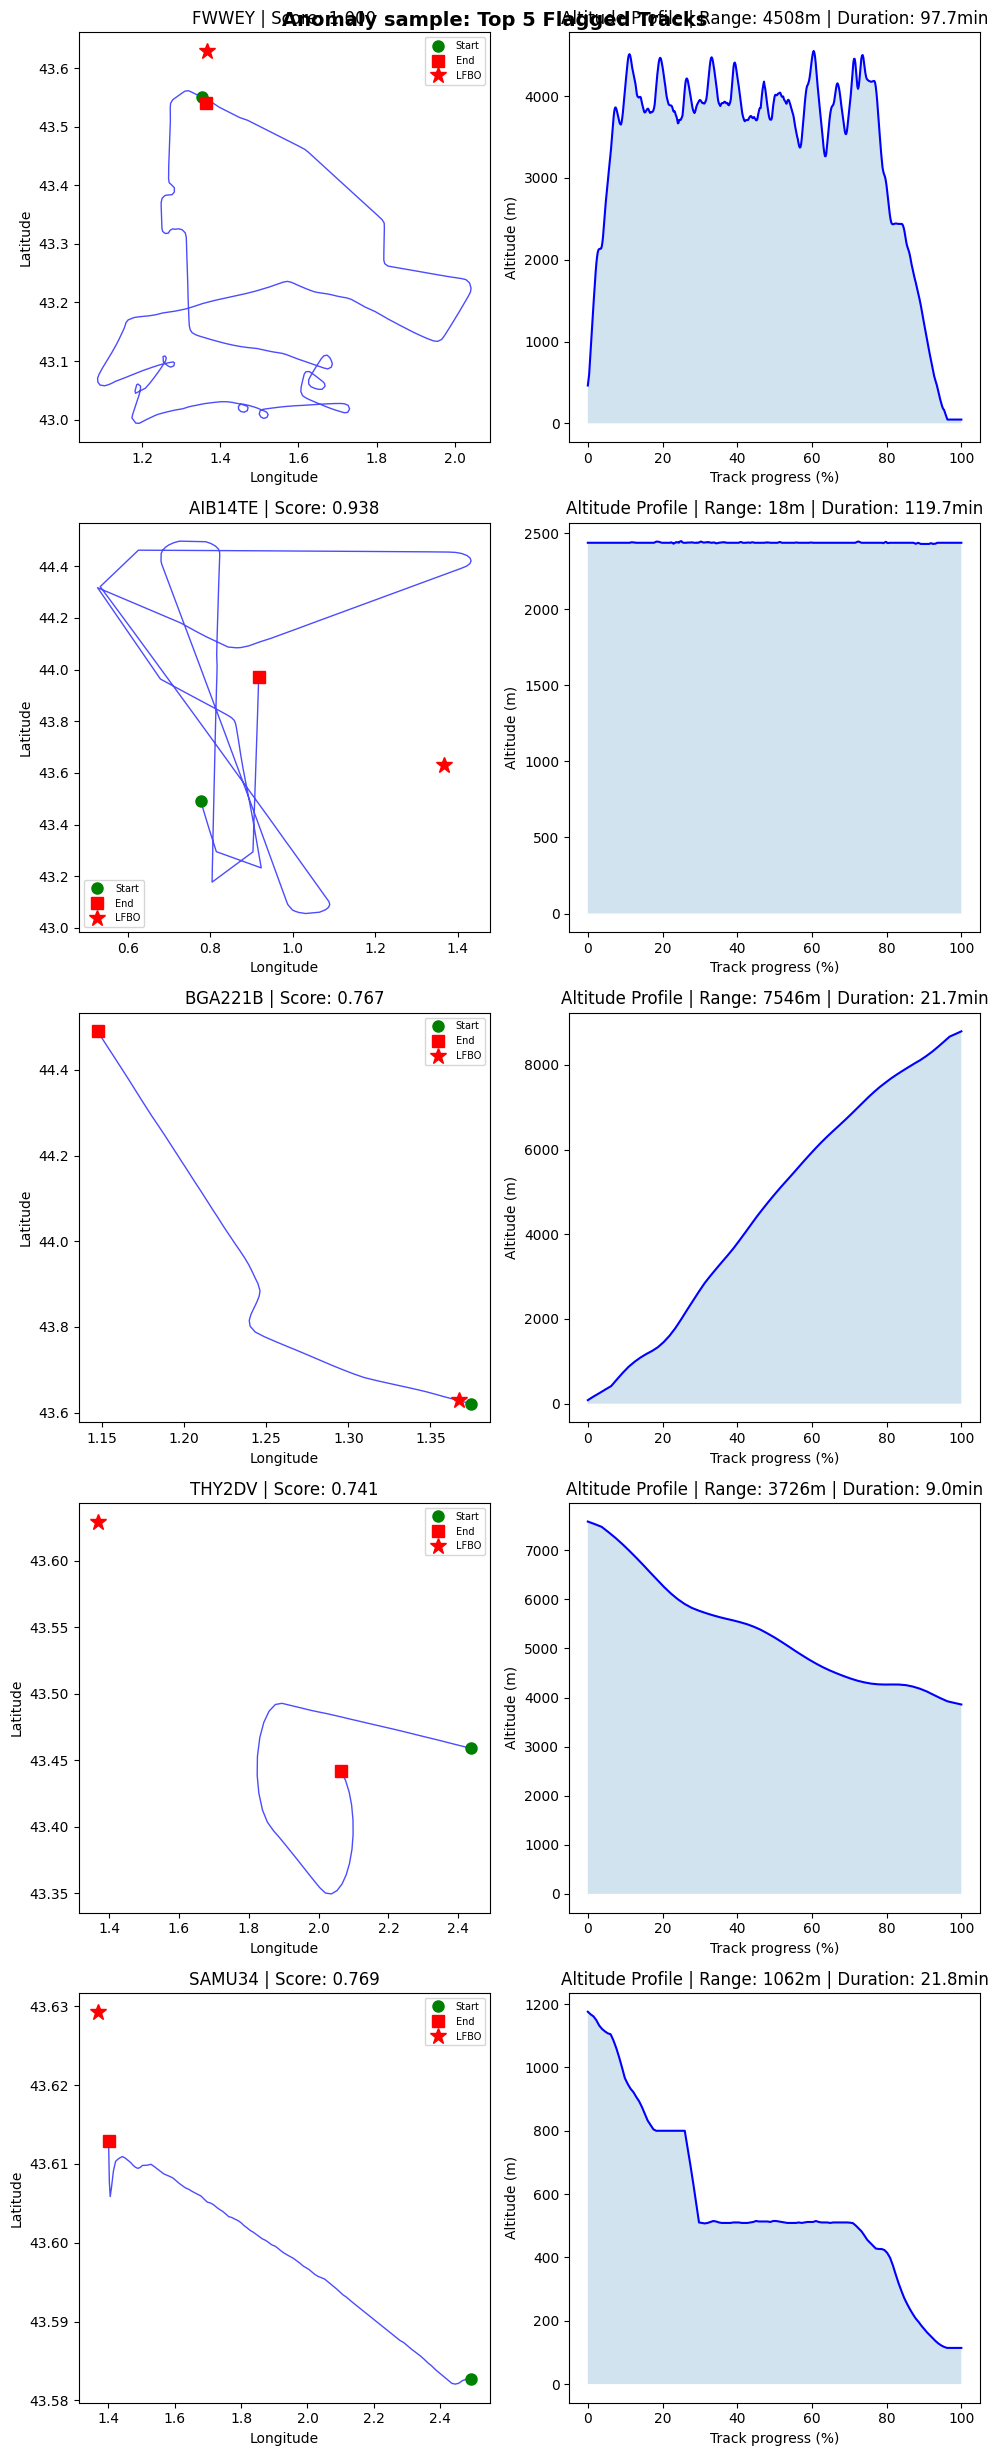

Saved anomaly_sample.png


In [ ]:
showcase = ["FWWEY", "AIB14TE", "BGA221B", "THY2DV", "SAMU34"]

fig, axes = plt.subplots(len(showcase), 2, figsize=(10, 5*len(showcase)))

for i, callsign in enumerate(showcase):
    row = df_results[df_results["callsign"].str.strip() == callsign].iloc[0]
    track = next(
        t for t in valid_tracks 
        if t.icao24 == row["icao24"]
    )
    pts = track.points.dropna(subset=["lat","lon","baroaltitude"])
    
    axes[i,0].plot(pts["lon"], pts["lat"], "b-", linewidth=1, alpha=0.7)
    axes[i,0].plot(pts["lon"].iloc[0], pts["lat"].iloc[0], "go", markersize=8, label="Start")
    axes[i,0].plot(pts["lon"].iloc[-1], pts["lat"].iloc[-1], "rs", markersize=8, label="End")
    axes[i,0].plot(LFBO_LON, LFBO_LAT,"r*", markersize=12, label="LFBO")
    axes[i,0].set_title(f"{callsign} | Score: {row['anomaly_score']:.3f}")
    axes[i,0].set_xlabel("Longitude")
    axes[i,0].set_ylabel("Latitude")
    axes[i,0].legend(fontsize=7)
    
    t_norm = np.linspace(0, 100, len(pts))
    axes[i,1].plot(t_norm, pts["baroaltitude"].values, "b-", linewidth=1.5)
    axes[i,1].fill_between(t_norm, pts["baroaltitude"].values, alpha=0.2)
    axes[i,1].set_title(
        f"Altitude Profile | "
        f"Range: {row['alt_range_m']:.0f}m | "
        f"Duration: {row['duration_min']:.1f}min"
    )
    axes[i,1].set_xlabel("Track progress (%)")
    axes[i,1].set_ylabel("Altitude (m)")

plt.tight_layout()
plt.savefig("figures/anomaly_sample.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved anomaly_sample.png")

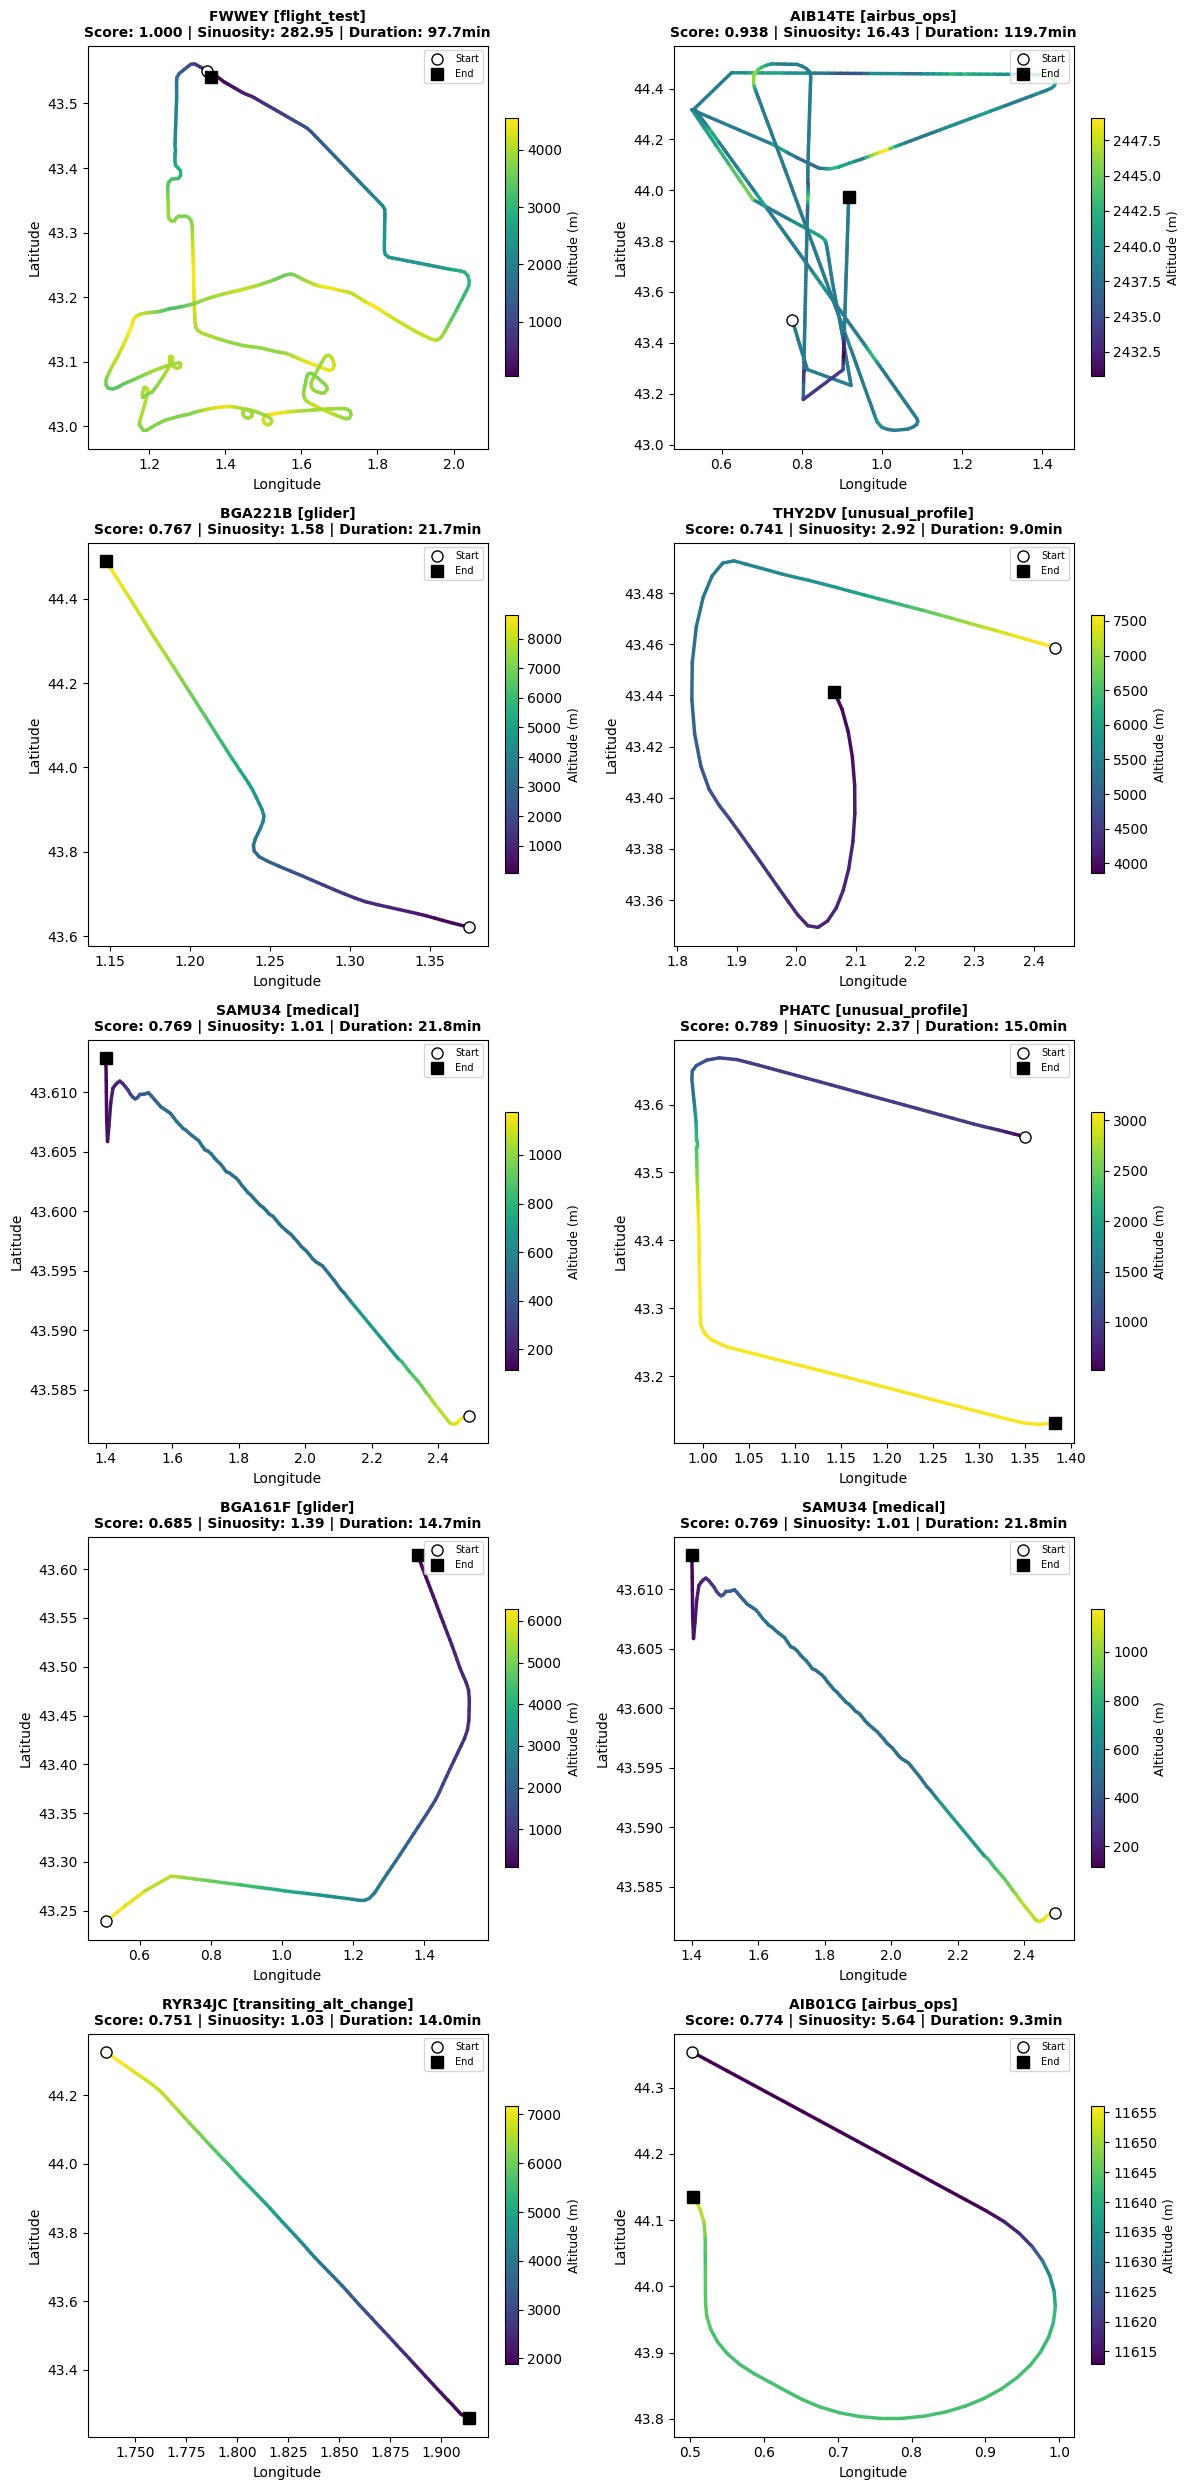

In [27]:
showcase = ["FWWEY", "AIB14TE", "BGA221B", "THY2DV", "SAMU34", "PHATC", "BGA161F", "SAMU34", "RYR34JC", "AIB01CG"]
general_colormap = False

n_plots = len(showcase)
n_cols  = 2
n_rows  = (n_plots + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5*n_rows))
axes_flat = axes.flatten()

cmap = plt.cm.viridis

if general_colormap:
    global_alt_min = np.inf
    global_alt_max = -np.inf

    for callsign in showcase:
        matches = df_results[df_results["callsign"].str.strip() == callsign]
        if len(matches) == 0:
            continue
        row = matches.iloc[0]
        track_matches = [t for t in valid_tracks if t.icao24 == row["icao24"]]
        if not track_matches:
            continue
        pts = track_matches[0].points.dropna(subset=["baroaltitude"])
        if len(pts) > 0:
            global_alt_min = min(global_alt_min, pts["baroaltitude"].min())
            global_alt_max = max(global_alt_max, pts["baroaltitude"].max())


for i, callsign in enumerate(showcase):
    ax = axes_flat[i]
    
    matches = df_results[df_results["callsign"].str.strip() == callsign]
    if len(matches) == 0:
        ax.set_visible(False)
        continue
    
    row = matches.iloc[0]
    track_matches = [t for t in valid_tracks if t.icao24 == row["icao24"]]
    if not track_matches:
        ax.set_visible(False)
        continue
    track = track_matches[0]
    
    pts = track.points.dropna(subset=["lat", "lon", "baroaltitude"]).reset_index(drop=True)
    
    if len(pts) < 3:
        ax.set_visible(False)
        continue
    
    lats = pts["lat"].values
    lons = pts["lon"].values
    alts = pts["baroaltitude"].values
    
    if general_colormap:
        alt_norm = (alts - global_alt_min) / (global_alt_max - global_alt_min + 1e-6)
        alt_min, alt_max = global_alt_min, global_alt_max
    else:
        alt_min, alt_max = alts.min(), alts.max()
        alt_norm = (alts - alt_min) / (alt_max - alt_min + 1e-6)
        
    for j in range(len(pts) - 1):
        color = cmap(alt_norm[j])
        ax.plot([lons[j], lons[j+1]], [lats[j], lats[j+1]], color=color, linewidth=2.5, solid_capstyle="round")
    
    ax.plot(lons[0],  lats[0],  "o", color="white", markersize=8, markeredgecolor="black", zorder=5, label="Start")
    ax.plot(lons[-1], lats[-1], "s", color="black", markersize=8, zorder=5, label="End")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=alt_min, vmax=alt_max))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label("Altitude (m)", fontsize=9)
    
    cat = anomaly_categories.get(callsign.strip(), "unknown")
    
    ax.set_title(
        f"{callsign} [{cat}]\n"
        f"Score: {row['anomaly_score']:.3f} | "
        f"Sinuosity: {row['sinuosity']:.2f} | "
        f"Duration: {row['duration_min']:.1f}min",
        fontsize=10, fontweight="bold"
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(fontsize=7, loc="upper right")

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig("figures/anomaly_sample_gradient.png", dpi=150, bbox_inches="tight")
plt.show()